## Testing whether the Multiple-Demand (MD) regions are real in PFC at individual level

In [1]:
import PcmPy as pcm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import exp, sqrt
import scipy.stats as sps
import os, pickle
import matplotlib as mpl
from py_util_dx.py_utils import setProjectPath, sqmat2vec
import Functional_Fusion.atlas_map as am
from py_util_dx.data_utils import get_roi_vtx_from_fs32k
from Functional_Fusion.reliability import flat2ndarray

In [2]:
mpl.rcParams['font.family'] = 'helvetica'   # Global font family
mpl.rcParams['font.size'] = 12              # Global font size 
full_width = 8.5
half_width = full_width/2

In [3]:
projectPath, mainResultsPath = setProjectPath()
dataset_name = 'Demand' # or Demand
surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')
resultsPath = os.path.join(mainResultsPath, '12_examine_MD_regions', f'{dataset_name}')
if not os.path.exists(resultsPath):
    os.makedirs(resultsPath)

In [4]:
atlas_str = 'fs32k'
atlas, ainf = am.get_atlas(atlas_str)

In [5]:
PKL_data = os.path.join(projectPath, 'data', f'{dataset_name}_CondHalf_all.pkl')
with open(PKL_data, 'rb') as pf:
    original_data = pickle.load(pf)
    X_individuals = original_data['X_individuals']
    info_individuals = original_data['info_individuals']
    dataset_obj_individuals = original_data['dataset_obj_individuals']

part_vec = list(info_individuals['half'])
cond_vec = list(info_individuals[dataset_obj_individuals.cond_ind])

# fill nans with 0
X_individuals[np.isnan(X_individuals)] = 0

In [6]:
X_individuals.shape 

(37, 24, 59518)

In [7]:
included_vtx_inds_LR, included_vtx_inds_L, included_vtx_inds_R, excluded_vtx_inds_LR = get_roi_vtx_from_fs32k('core_MD_frontal') 
# included_vtx_inds_LR, included_vtx_inds_L, included_vtx_inds_R, excluded_vtx_inds_LR = get_roi_vtx_from_fs32k('non_MD_frontal') 

In [8]:
X_individuals = X_individuals[:, :, included_vtx_inds_LR] 
X_individuals.shape 

(37, 24, 2026)

In [9]:
print(part_vec)

[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [10]:
print(cond_vec)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [11]:
info_individuals

,half,task_code,cond_code,n_rep,task_name,cond_name,names,cond_num,sess
0,2,dmndnbck,e_face,2.0,n_back,nback_E_face,dmndnbck_e_face_half2,1,ses-01
1,2,dmndnbck,e_house,2.0,n_back,nback_E_house,dmndnbck_e_house_half2,2,ses-01
2,2,dmndnbck,h_face,2.0,n_back,nback_H_face,dmndnbck_h_face_half2,3,ses-01
3,2,dmndnbck,h_house,2.0,n_back,nback_H_house,dmndnbck_h_house_half2,4,ses-01
4,2,dmndswitch,e_face,2.0,switch,switch_E_face,dmndswitch_e_face_half2,5,ses-01
5,2,dmndswitch,e_house,2.0,switch,switch_E_house,dmndswitch_e_house_half2,6,ses-01
6,2,dmndswitch,h_face,2.0,switch,switch_H_face,dmndswitch_h_face_half2,7,ses-01
7,2,dmndswitch,h_house,2.0,switch,switch_H_house,dmndswitch_h_house_half2,8,ses-01
8,2,dmndstop,e_face,2.0,stop,stop_E_face,dmndstop_e_face_half2,9,ses-01
9,2,dmndstop,e_house,2.0,stop,stop_E_house,dmndstop_e_house_half2,10,ses-01


In [12]:
# whole cortex
data = flat2ndarray(X_individuals, part_vec, cond_vec)
data.shape 

(37, 2, 12, 2026)

In [13]:
n_subjects, n_parts, _, n_vertices = data.shape 

In [14]:
data = data.reshape(n_subjects, n_parts, 3, 2, 2, n_vertices) 
data.shape  # n_subjects x n_parts x n_tasks x n_diff x n_stimuli x n_vertices 

(37, 2, 3, 2, 2, 2026)

In [15]:
data = data.mean(axis=-2) 
data.shape  # n_subjects x n_parts x n_tasks x n_diff x n_vertices 

(37, 2, 3, 2, 2026)

In [16]:
data = data[:, :, :, 1] - data[:, :, :, 0]  # hard - easy 
data.shape  # n_subjects x n_parts x n_tasks x n_vertices 

(37, 2, 3, 2026)

In [17]:
D_01 = []
for subjI in np.arange(n_subjects):
    d = pcm.Dataset(
        measurements=np.take(data[subjI], [0, 1], axis=1).reshape(-1, n_vertices), 
        obs_descriptors = {'cond_vec': np.array([0, 1, 0, 1]), 'part_vec': np.array([0, 0, 1, 1])} 
    )
    D_01.append(d) 


D_02 = []
for subjI in np.arange(n_subjects):
    d = pcm.Dataset(
        measurements=np.take(data[subjI],[0, 2], axis=1).reshape(-1, n_vertices), 
        obs_descriptors = {'cond_vec': np.array([0, 1, 0, 1]), 'part_vec': np.array([0, 0, 1, 1])} 
    )
    D_02.append(d) 

D_12 = []
for subjI in np.arange(n_subjects):
    d = pcm.Dataset(
        measurements=np.take(data[subjI],[1, 2], axis=1).reshape(-1, n_vertices), 
        obs_descriptors = {'cond_vec': np.array([0, 1, 0, 1]), 'part_vec': np.array([0, 0, 1, 1])} 
    )
    D_12.append(d) 

In [18]:
def get_corr(X,cond_vec):
    """
        Get normal correlation
    """
    p1 = X[cond_vec==0,:].mean(axis=0)
    p2 = X[cond_vec==1,:].mean(axis=0)

    return np.corrcoef(p1,p2)[0,1]

In [19]:
r_01 = [] 

for subjI in np.arange(n_subjects):
    d = D_01[subjI].measurements 
    r_01.append(get_corr(d, np.array([0, 1, 0, 1])))

print(np.array(r_01)) 
print(f'estimated mean r across subjects: {np.mean(r_01):.4f}') 

[0.82304662 0.70280255 0.70958366 0.7310455  0.60694641 0.79010591
 0.7039866  0.42820994 0.56103547 0.63301077 0.62771972 0.44577037
 0.68462717 0.7706064  0.69499742 0.37618142 0.60488399 0.52843066
 0.84792756 0.72956446 0.10570571 0.6571606  0.77000088 0.44243112
 0.49300518 0.73003321 0.77399088 0.81729899 0.77312234 0.6746104
 0.73930427 0.75838257 0.81598374 0.76464467 0.7416323  0.82570043
 0.44126087]
estimated mean r across subjects: 0.6574


In [20]:
r_02 = [] 

for subjI in np.arange(n_subjects):
    d = D_02[subjI].measurements 
    r_02.append(get_corr(d, np.array([0, 1, 0, 1])))

print(np.array(r_02)) 
print(f'estimated mean r across subjects: {np.mean(r_02):.4f}') 

[ 0.3463321   0.48177019  0.37064083  0.16027025  0.31816177  0.23102603
 -0.01646121 -0.16710612  0.17342952  0.52818616  0.18979508  0.52820854
  0.54184441  0.28674029  0.3646424   0.07842152  0.03508812  0.3129522
  0.23488384  0.6631063   0.29306011  0.21117114  0.28228901 -0.08991896
  0.28462154  0.42466443 -0.1492193   0.13899008  0.34743657 -0.05440024
  0.45077773  0.09362452  0.24432581  0.40661225  0.09429437  0.36159453
  0.28505985]
estimated mean r across subjects: 0.2510


In [21]:
r_12 = [] 

for subjI in np.arange(n_subjects):
    d = D_12[subjI].measurements 
    r_12.append(get_corr(d, np.array([0, 1, 0, 1])))

print(np.array(r_12)) 
print(f'estimated mean r across subjects: {np.mean(r_12):.4f}') 

[ 0.35099159  0.18935305  0.19538524  0.06550851  0.23674326  0.0636809
 -0.00526207 -0.07213349  0.18508792  0.25822333 -0.0279364   0.28427725
  0.4499074   0.08476564  0.19869576  0.05412148  0.3638034   0.00423553
  0.03155669  0.34949947  0.26974063 -0.24609596  0.01892722 -0.07196101
 -0.06046795  0.01881512 -0.22965311  0.06594787  0.18976619 -0.018996
  0.41233149  0.31477326  0.04942169  0.27029082  0.01883076  0.23780513
 -0.12560624]
estimated mean r across subjects: 0.1182


In [22]:
r = [] 

for d in data:
    corr = sqmat2vec(np.corrcoef(d.mean(axis=0)))
    r.append(corr) 

np.array(r) 

array([[ 0.82304662,  0.3463321 ,  0.35099159],
       [ 0.70280255,  0.48177019,  0.18935305],
       [ 0.70958366,  0.37064083,  0.19538524],
       [ 0.7310455 ,  0.16027025,  0.06550851],
       [ 0.60694641,  0.31816177,  0.23674326],
       [ 0.79010591,  0.23102603,  0.0636809 ],
       [ 0.7039866 , -0.01646121, -0.00526207],
       [ 0.42820994, -0.16710612, -0.07213349],
       [ 0.56103547,  0.17342952,  0.18508792],
       [ 0.63301077,  0.52818616,  0.25822333],
       [ 0.62771972,  0.18979508, -0.0279364 ],
       [ 0.44577037,  0.52820854,  0.28427725],
       [ 0.68462717,  0.54184441,  0.4499074 ],
       [ 0.7706064 ,  0.28674029,  0.08476564],
       [ 0.69499742,  0.3646424 ,  0.19869576],
       [ 0.37618142,  0.07842152,  0.05412148],
       [ 0.60488399,  0.03508812,  0.3638034 ],
       [ 0.52843066,  0.3129522 ,  0.00423553],
       [ 0.84792756,  0.23488384,  0.03155669],
       [ 0.72956446,  0.6631063 ,  0.34949947],
       [ 0.10570571,  0.29306011,  0.269

In [23]:
# data[0, :, np.ix_([0, 1])] 
np.take(data[0], [0, 1], axis=1)

array([[[ 0.92277777,  0.31574489,  0.29818573, ...,  0.58701711,
          0.60414779,  0.88084983],
        [ 1.12938932,  0.22145047,  0.26628527, ...,  0.55377069,
          0.64233082,  0.92449033]],

       [[ 0.76607018, -0.09869051,  0.00938284, ...,  0.39698652,
          0.47159848,  0.59743322],
        [ 0.96371139,  0.16130726,  0.16237061, ...,  0.57830815,
          0.71187701,  0.99734732]]], shape=(2, 2, 2026))

In [24]:
data[0, :, 0:2]

array([[[ 0.92277777,  0.31574489,  0.29818573, ...,  0.58701711,
          0.60414779,  0.88084983],
        [ 1.12938932,  0.22145047,  0.26628527, ...,  0.55377069,
          0.64233082,  0.92449033]],

       [[ 0.76607018, -0.09869051,  0.00938284, ...,  0.39698652,
          0.47159848,  0.59743322],
        [ 0.96371139,  0.16130726,  0.16237061, ...,  0.57830815,
          0.71187701,  0.99734732]]], shape=(2, 2, 2026))

In [25]:
data[0]

array([[[ 0.92277777,  0.31574489,  0.29818573, ...,  0.58701711,
          0.60414779,  0.88084983],
        [ 1.12938932,  0.22145047,  0.26628527, ...,  0.55377069,
          0.64233082,  0.92449033],
        [ 0.24323949,  0.19005569,  0.28221485, ...,  0.38058421,
          0.70907123,  0.95701317]],

       [[ 0.76607018, -0.09869051,  0.00938284, ...,  0.39698652,
          0.47159848,  0.59743322],
        [ 0.96371139,  0.16130726,  0.16237061, ...,  0.57830815,
          0.71187701,  0.99734732],
        [ 0.37016832,  0.12744564,  0.23410538, ...,  0.52564395,
          0.81454958,  1.09907246]]], shape=(2, 3, 2026))

In [26]:
n_part = 2

CIs_bootstrp = [] 

In [27]:
# Now make the flexible model
Mflex_sim = pcm.CorrelationModel("flex", num_items=1, corr=None, cond_effect=False)
print(f"The flexible model has {Mflex_sim.n_param} hyper parameters")

The flexible model has 3 hyper parameters


In [28]:
# In this case, we the mean of the block is not modelled
# This is valid if the measurement noise for A and B within a block are independent.
# We don't need to include a scale parameter given that we don't have a fixed model
T_01, theta_01 = pcm.fit_model_individ(D_01, Mflex_sim, fixed_effect=None, fit_scale=False, verbose=False)
T_01.head()

variable,likelihood,noise,iterations
model,flex,flex,flex
0,7339.963028,0.016039,8.0
1,6310.975574,0.031460,7.0
2,6422.711705,0.032727,7.0
3,5889.098831,0.025829,6.0
4,7708.374735,0.019173,6.0


In [29]:
# We can either include or not include a individual scale factor.
# Given that that the variance parameters (and correlation parameter) are  the same across the entire group, but
# since we cannot assume that the signal-to-noise ratio is the same across participants, we include a scale factor.
T_gr_01, theta_gr_01 = pcm.fit_model_group(D_01, Mflex_sim, fixed_effect=None, fit_scale=True, verbose=False)
T_gr_01.head() 

variable,likelihood,noise,scale,iterations
model,flex,flex,flex,flex
0,7010.861101,0.015388,1.444837,12
1,6248.833496,0.030267,0.884060,12
2,6338.405300,0.030713,0.813920,12
3,5870.188808,0.026235,1.381105,12
4,7600.715397,0.019675,0.737137,12


In [30]:
# Get the individual parameter estimates from the individual fits
theta_ind_01 = theta_01[0] # Get the parameters from the first (and only model)
r_indiv_01 = Mflex_sim.get_correlation(theta_ind_01) # Inverse fisher-z transform
fSNR_indiv_01 = Mflex_sim.get_fSNR(theta_ind_01, n_part, separate=False)

In [31]:
# Add the group estimate as a horizontal line
theta_g_01, _ = pcm.group_to_individ_param(theta_gr_01[0], Mflex_sim, n_subjects) 
r_group_01 = Mflex_sim.get_correlation(theta_g_01) 

Text(0.5, 1.0, 'task 0, 1')

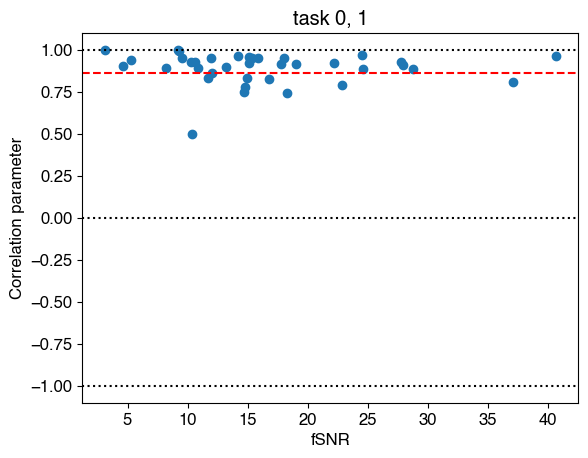

In [32]:
# Make the diagnostic plot of the correlation parameter against the fSNR
plt.scatter(fSNR_indiv_01, r_indiv_01)
plt.axhline(r_group_01[0], color='red', linestyle='--')
plt.axhline(1, color='k', linestyle=':')
plt.axhline(-1, color='k', linestyle=':')
plt.axhline(0, color='k', linestyle=':')
plt.xlabel('fSNR')
plt.ylabel('Correlation parameter')
plt.title('task 0, 1') 

In [33]:
r_boot, fSNR_boot, _ = pcm.bootstrap_group_corr(D_01, Mflex_sim, fixed_effect=None, n_bootstr=200, verbose=True)

Bootstrapping 200 samples: 
Bootstrap sample 0/200
Bootstrap sample 50/200
Bootstrap sample 100/200
Bootstrap sample 150/200


CI low = 0.8287545282755334, CI high = 0.8942910128879668


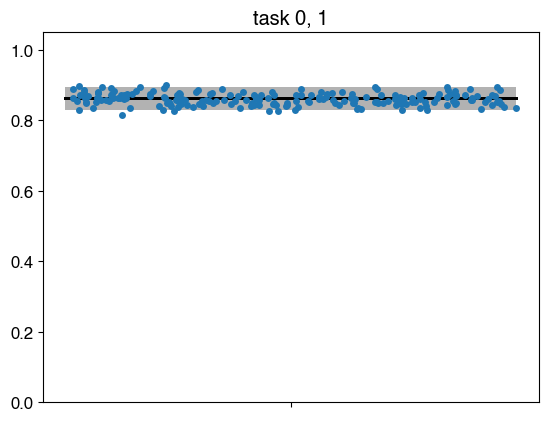

In [34]:
ax=sns.stripplot(y=r_boot,dodge=True,legend=False)
ax.set_ylim([0,1.05])
x_coord = ax.get_xticks()
CI_low = np.percentile(r_boot, 2.5)
CI_high = np.percentile(r_boot, 97.5)
pcm.plot_CI(ax,x_coord[0],center=r_group_01,low=CI_low,high=CI_high,width=0.2,facecolor='black',alpha=0.3)

plt.title('task 0, 1') 

print(f'CI low = {CI_low}, CI high = {CI_high}')
CIs_bootstrp.append((CI_low, CI_high))

Text(0.5, 1.0, 'task 0, 2')

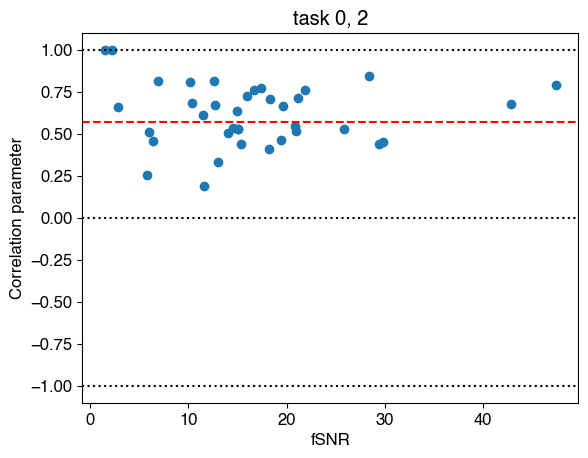

In [35]:
T_02, theta_02 = pcm.fit_model_individ(D_02, Mflex_sim, fixed_effect=None, fit_scale=False, verbose=False)
T_02.head()

T_gr_02, theta_gr_02 = pcm.fit_model_group(D_02, Mflex_sim, fixed_effect=None, fit_scale=True, verbose=False)
T_gr_02.head() 

theta_ind_02 = theta_02[0] # Get the parameters from the first (and only model)
r_indiv_02 = Mflex_sim.get_correlation(theta_02[0]) # Inverse fisher-z transform
fSNR_indiv_02 = Mflex_sim.get_fSNR(theta_02[0], n_part, separate=False)

theta_g_02, _ = pcm.group_to_individ_param(theta_gr_02[0], Mflex_sim, n_subjects) 
r_group_02 = Mflex_sim.get_correlation(theta_g_02) 

plt.scatter(fSNR_indiv_02, r_indiv_02)
plt.axhline(r_group_02[0], color='red', linestyle='--')
plt.axhline(1, color='k', linestyle=':')
plt.axhline(-1, color='k', linestyle=':')
plt.axhline(0, color='k', linestyle=':')
plt.xlabel('fSNR')
plt.ylabel('Correlation parameter')
plt.title('task 0, 2') 

Bootstrapping 200 samples: 
Bootstrap sample 0/200
Bootstrap sample 50/200
Bootstrap sample 100/200
Bootstrap sample 150/200
CI low = 0.5362584431041857, CI high = 0.6379347755569497


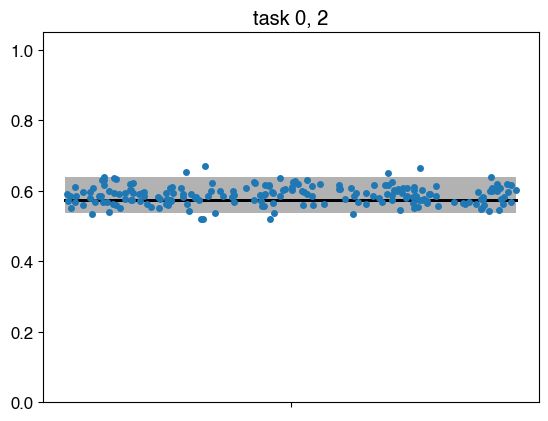

In [36]:
r_boot, fSNR_boot, _ = pcm.bootstrap_group_corr(D_02, Mflex_sim, fixed_effect=None, n_bootstr=200, verbose=True)

ax=sns.stripplot(y=r_boot,dodge=True,legend=False)
ax.set_ylim([0,1.05])
x_coord = ax.get_xticks()
CI_low = np.percentile(r_boot, 2.5)
CI_high = np.percentile(r_boot, 97.5)
pcm.plot_CI(ax,x_coord[0],center=r_group_02,low=CI_low,high=CI_high,width=0.2,facecolor='black',alpha=0.3)

plt.title('task 0, 2') 

print(f'CI low = {CI_low}, CI high = {CI_high}')
CIs_bootstrp.append((CI_low, CI_high))

Text(0.5, 1.0, 'task 1, 2')

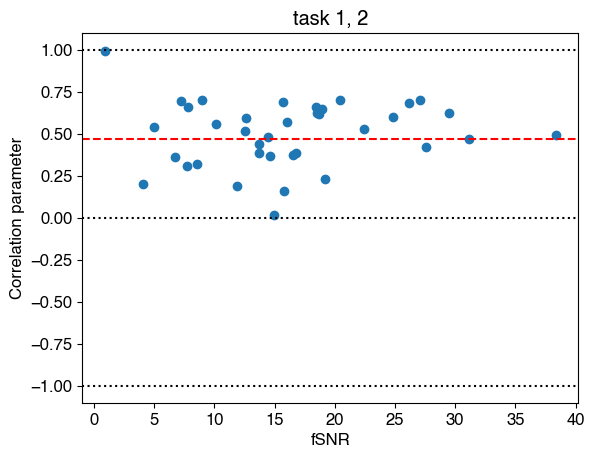

In [37]:
T_12, theta_12 = pcm.fit_model_individ(D_12, Mflex_sim, fixed_effect=None, fit_scale=False, verbose=False)
T_12.head()

T_gr_12, theta_gr_12 = pcm.fit_model_group(D_12, Mflex_sim, fixed_effect=None, fit_scale=True, verbose=False)
T_gr_12.head() 

theta_ind_12 = theta_12[0] # Get the parameters from the first (and only model)
r_indiv_12 = Mflex_sim.get_correlation(theta_12[0]) # Inverse fisher-z transform
fSNR_indiv_12 = Mflex_sim.get_fSNR(theta_12[0], n_part, separate=False)

theta_g_12, _ = pcm.group_to_individ_param(theta_gr_12[0], Mflex_sim, n_subjects) 
r_group_12 = Mflex_sim.get_correlation(theta_g_12) 

plt.scatter(fSNR_indiv_12, r_indiv_12)
plt.axhline(r_group_12[0], color='red', linestyle='--')
plt.axhline(1, color='k', linestyle=':')
plt.axhline(-1, color='k', linestyle=':')
plt.axhline(0, color='k', linestyle=':')
plt.xlabel('fSNR')
plt.ylabel('Correlation parameter')
plt.title('task 1, 2') 

Bootstrapping 200 samples: 
Bootstrap sample 0/200
Bootstrap sample 50/200
Bootstrap sample 100/200
Bootstrap sample 150/200
CI low = 0.41775136638321314, CI high = 0.5323455294222115


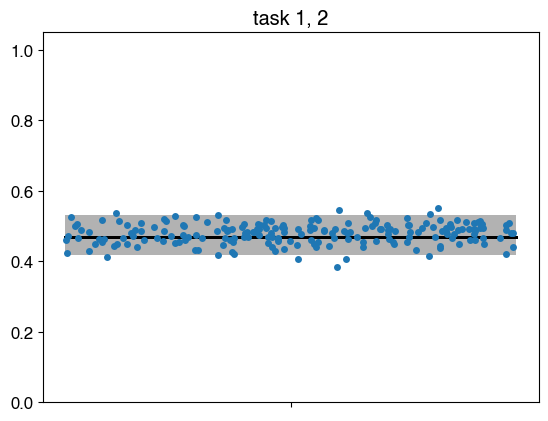

In [38]:
r_boot, fSNR_boot, _ = pcm.bootstrap_group_corr(D_12, Mflex_sim, fixed_effect=None, n_bootstr=200, verbose=True)

ax=sns.stripplot(y=r_boot,dodge=True,legend=False)
ax.set_ylim([0,1.05])
x_coord = ax.get_xticks()
CI_low = np.percentile(r_boot, 2.5)
CI_high = np.percentile(r_boot, 97.5)
pcm.plot_CI(ax,x_coord[0],center=r_group_12,low=CI_low,high=CI_high,width=0.2,facecolor='black',alpha=0.3)

plt.title('task 1, 2') 

print(f'CI low = {CI_low}, CI high = {CI_high}')
CIs_bootstrp.append((CI_low, CI_high))

### group-averaged data 

In [39]:
data = data.mean(axis=0) 
data.shape  # n_parts x n_tasks x n_vertices 

(2, 3, 2026)

In [40]:
D_g01 = [
    pcm.Dataset(
    measurements=np.take(data, [0, 1], axis=1).reshape(-1, n_vertices), 
    obs_descriptors = {'cond_vec': np.array([0, 1, 0, 1]), 'part_vec': np.array([0, 0, 1, 1])} 
    )]

D_g02 = [
    pcm.Dataset(
    measurements=np.take(data, [0, 2], axis=1).reshape(-1, n_vertices), 
    obs_descriptors = {'cond_vec': np.array([0, 1, 0, 1]), 'part_vec': np.array([0, 0, 1, 1])} 
    )]

D_g12 = [
    pcm.Dataset(
    measurements=np.take(data, [1, 2], axis=1).reshape(-1, n_vertices), 
    obs_descriptors = {'cond_vec': np.array([0, 1, 0, 1]), 'part_vec': np.array([0, 0, 1, 1])} 
    )]

In [41]:
np.corrcoef(data.mean(axis=0)) 

array([[ 1.        ,  0.77458995,  0.23984499],
       [ 0.77458995,  1.        , -0.05173119],
       [ 0.23984499, -0.05173119,  1.        ]])

In [42]:
T_g01, theta_g01 = pcm.fit_model_individ(D_g01, Mflex_sim, fixed_effect=None, fit_scale=False, verbose=False)
T_g01.head()

variable,likelihood,noise,iterations
model,flex,flex,flex
0,15111.770438,0.000923,7.0


In [43]:
theta_ind_g01 = theta_g01[0] # Get the parameters from the first (and only model)
r_g01 = Mflex_sim.get_correlation(theta_g01[0]) # Inverse fisher-z transform
fSNR_g01 = Mflex_sim.get_fSNR(theta_g01[0], n_part, separate=False)
r_g01 

array([0.94330044])

In [44]:
T_g02, theta_g02 = pcm.fit_model_individ(D_g02, Mflex_sim, fixed_effect=None, fit_scale=False, verbose=False)
T_g02.head()

r_g02 = Mflex_sim.get_correlation(theta_g02[0]) # Inverse fisher-z transform
fSNR_g02 = Mflex_sim.get_fSNR(theta_g02[0], n_part, separate=False)
r_g02 

array([0.76109924])

In [45]:
T_g12, theta_g12 = pcm.fit_model_individ(D_g12, Mflex_sim, fixed_effect=None, fit_scale=False, verbose=False)
T_g12.head()

r_g12 = Mflex_sim.get_correlation(theta_g12[0]) # Inverse fisher-z transform
fSNR_g12 = Mflex_sim.get_fSNR(theta_g12[0], n_part, separate=False)
r_g12 

array([0.62630646])

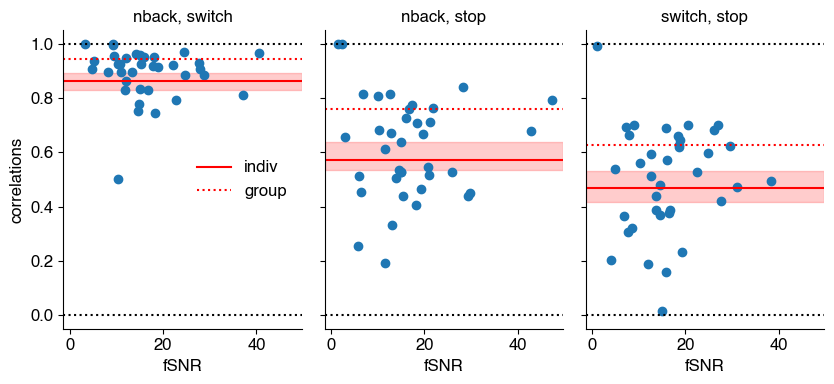

In [46]:
fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(full_width, 4))
# fig.set_figwidth(full_width) 

fSNR_indiv_list = [fSNR_indiv_01, fSNR_indiv_02, fSNR_indiv_12]
r_indiv_list = [r_indiv_01, r_indiv_02, r_indiv_12]
r_indv_mean_list = [r_group_01[0], r_group_02[0], r_group_12[0]]
r_group_list = [r_g01, r_g02, r_g12]

titles = ['nback, switch', 'nback, stop', 'switch, stop']

for i in np.arange(3):     
    ax[i].axhline(r_indv_mean_list[i], color='red', linestyle='-', label='indiv')    
    ax[i].axhspan(CIs_bootstrp[i][0], CIs_bootstrp[i][1], color='red', alpha=0.2) # Fill CI
    ax[i].axhline(r_group_list[i], color='red', linestyle=':', label='group')
    ax[i].axhline(1, color='k', linestyle=':')    
    ax[i].axhline(0, color='k', linestyle=':')    
    ax[i].scatter(fSNR_indiv_list[i], r_indiv_list[i])
    ax[i].set_ylim([-0.05, 1.05])
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_title(titles[i], fontsize=12)
    ax[i].set_xlabel('fSNR', fontsize=12)
    ax[i].tick_params(axis='x', labelsize=12)
    ax[i].tick_params(axis='y', labelsize=12)
    if i == 0:
        ax[i].set_ylabel('correlations', fontsize=12)
        ax[i].legend(frameon=False, fontsize=12) 

plt.tight_layout()

JPG_fig = os.path.join(resultsPath, f'individual_correlations_{dataset_name}.jpg') 
plt.savefig(JPG_fig, format='jpg', dpi=500) 

In [47]:
(np.array([x[0] for x in r_group_list]) - np.array(r_indv_mean_list)) / np.array(r_indv_mean_list)

array([0.09372537, 0.32717757, 0.33469781])

In [50]:
(np.array([x[0] for x in r_group_list]) - np.array(r_indv_mean_list)) / np.array([x[0] for x in r_group_list])

array([0.08569369, 0.24652132, 0.25076674])

In [51]:
r_indv_mean_list

[np.float64(0.8624655378197473),
 np.float64(0.5734720487318506),
 np.float64(0.4692496317588492)]